In [1]:
import os
import numpy as np
from PIL import Image

dataset_path = r"D:\Smartvision_project\smartvision_dataset\classification\train"

black_border_images = []
total_images = 0

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):
        if not file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        image_path = os.path.join(class_path, file_name)
        total_images += 1

        try:
            img = Image.open(image_path).convert("RGB")
            arr = np.array(img)

            h, w, _ = arr.shape

            # Check black pixels along the borders
            top = arr[:max(1, int(h * 0.10)), :, :]
            bottom = arr[-max(1, int(h * 0.10)):, :, :]
            left = arr[:, :max(1, int(w * 0.10)), :]
            right = arr[:, -max(1, int(w * 0.10)):, :]

            border_pixels = np.concatenate([
                top.reshape(-1, 3),
                bottom.reshape(-1, 3),
                left.reshape(-1, 3),
                right.reshape(-1, 3)
            ])

            black_pixels = np.all(border_pixels < 10, axis=1)
            black_percentage = np.mean(black_pixels) * 100

            if black_percentage > 50:
                black_border_images.append(
                    (image_path, black_percentage)
                )

        except Exception as e:
            print("Error:", image_path, e)

print("=" * 60)
print("🖼️ BLACK BORDER CHECK")
print("=" * 60)
print("Total training images:", total_images)
print("Images with >50% black border pixels:", len(black_border_images))

if black_border_images:
    print("\nExamples:")
    for path, percentage in black_border_images[:20]:
        print(f"{percentage:.2f}%  |  {path}")

print("=" * 60)

🖼️ BLACK BORDER CHECK
Total training images: 1750
Images with >50% black border pixels: 781

Examples:
71.74%  |  D:\Smartvision_project\smartvision_dataset\classification\train\airplane\airplane_train_0050.jpg
77.92%  |  D:\Smartvision_project\smartvision_dataset\classification\train\airplane\airplane_train_0056.jpg
60.82%  |  D:\Smartvision_project\smartvision_dataset\classification\train\bed\bed_train_0001.jpg
55.15%  |  D:\Smartvision_project\smartvision_dataset\classification\train\bed\bed_train_0002.jpg
81.61%  |  D:\Smartvision_project\smartvision_dataset\classification\train\bed\bed_train_0003.jpg
57.14%  |  D:\Smartvision_project\smartvision_dataset\classification\train\bed\bed_train_0010.jpg
50.64%  |  D:\Smartvision_project\smartvision_dataset\classification\train\bed\bed_train_0011.jpg
52.64%  |  D:\Smartvision_project\smartvision_dataset\classification\train\bed\bed_train_0012.jpg
85.40%  |  D:\Smartvision_project\smartvision_dataset\classification\train\bed\bed_train_0013

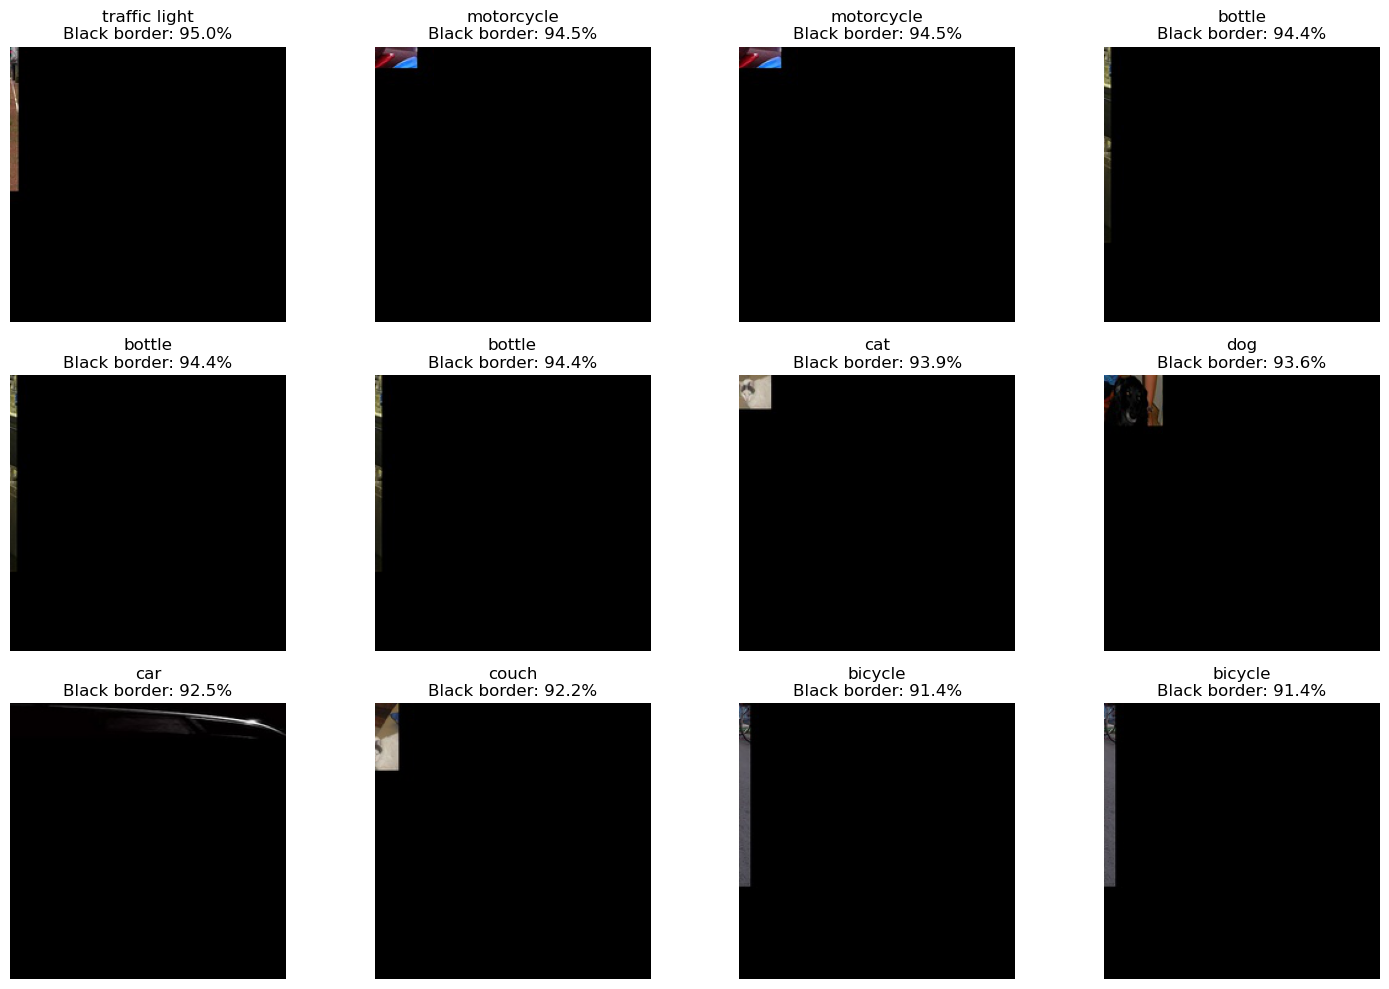

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

# Show 12 images with the highest black-border percentage
worst_images = sorted(
    black_border_images,
    key=lambda x: x[1],
    reverse=True
)[:12]

plt.figure(figsize=(15, 10))

for i, (image_path, percentage) in enumerate(worst_images):
    img = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(
        f"{os.path.basename(os.path.dirname(image_path))}\n"
        f"Black border: {percentage:.1f}%"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [3]:
from collections import Counter

# Count severely black-bordered images (>90%) by class
severe_counts = Counter()

for image_path, percentage in black_border_images:
    if percentage > 90:
        class_name = os.path.basename(os.path.dirname(image_path))
        severe_counts[class_name] += 1

print("=" * 60)
print("🚨 SEVERE BLACK-BORDER IMAGES (>90%)")
print("=" * 60)

for class_name in sorted(severe_counts):
    print(f"{class_name:<20}: {severe_counts[class_name]}")

print("-" * 60)
print("Total severe images:", sum(severe_counts.values()))
print("=" * 60)

🚨 SEVERE BLACK-BORDER IMAGES (>90%)
bicycle             : 6
bottle              : 3
car                 : 1
cat                 : 1
couch               : 2
dog                 : 1
motorcycle          : 2
traffic light       : 1
------------------------------------------------------------
Total severe images: 17


In [4]:
import os
import shutil

original_train = r"D:\Smartvision_project\smartvision_dataset\classification\train"
cleaned_train = r"D:\Smartvision_project\smartvision_dataset\classification_cleaned\train"

# Create cleaned training directory
os.makedirs(cleaned_train, exist_ok=True)

removed = 0
copied = 0

for class_name in os.listdir(original_train):

    source_class = os.path.join(original_train, class_name)

    if not os.path.isdir(source_class):
        continue

    destination_class = os.path.join(cleaned_train, class_name)
    os.makedirs(destination_class, exist_ok=True)

    for file_name in os.listdir(source_class):

        source_file = os.path.join(source_class, file_name)

        if not file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        # Check if this image was identified as >90% black
        is_severe = False

        for image_path, percentage in black_border_images:
            if image_path == source_file and percentage > 90:
                is_severe = True
                break

        if is_severe:
            removed += 1
            continue

        # Copy good image to cleaned dataset
        destination_file = os.path.join(destination_class, file_name)
        shutil.copy2(source_file, destination_file)
        copied += 1

print("=" * 60)
print("🧹 CLEANED TRAINING DATASET")
print("=" * 60)
print("Original images :", copied + removed)
print("Removed images  :", removed)
print("Cleaned images  :", copied)
print("Saved to        :", cleaned_train)
print("=" * 60)

🧹 CLEANED TRAINING DATASET
Original images : 1750
Removed images  : 17
Cleaned images  : 1733
Saved to        : D:\Smartvision_project\smartvision_dataset\classification_cleaned\train


In [5]:
import os

cleaned_train = r"D:\Smartvision_project\smartvision_dataset\classification_cleaned\train"

print("=" * 60)
print("📊 CLEANED TRAINING CLASS DISTRIBUTION")
print("=" * 60)

total = 0

for class_name in sorted(os.listdir(cleaned_train)):
    class_path = os.path.join(cleaned_train, class_name)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        print(f"{class_name:<20}: {count}")
        total += count

print("-" * 60)
print("Total cleaned training images:", total)
print("=" * 60)

📊 CLEANED TRAINING CLASS DISTRIBUTION
airplane            : 70
bed                 : 70
bench               : 70
bicycle             : 64
bird                : 70
bottle              : 67
bowl                : 70
bus                 : 70
cake                : 70
car                 : 69
cat                 : 69
chair               : 70
couch               : 68
cow                 : 70
cup                 : 70
dog                 : 69
elephant            : 70
horse               : 70
motorcycle          : 68
person              : 70
pizza               : 70
potted plant        : 70
stop sign           : 70
traffic light       : 69
truck               : 70
------------------------------------------------------------
Total cleaned training images: 1733


In [6]:
import os
import shutil
import cv2

BASE_PATH = r"D:\Smartvision_project\smartvision_dataset\classification"

VAL_SOURCE = os.path.join(BASE_PATH, "val")
VAL_CLEANED = r"D:\Smartvision_project\smartvision_dataset\classification_cleaned\val"

os.makedirs(VAL_CLEANED, exist_ok=True)

removed = 0
kept = 0

for class_name in os.listdir(VAL_SOURCE):

    class_source = os.path.join(VAL_SOURCE, class_name)

    if not os.path.isdir(class_source):
        continue

    class_dest = os.path.join(VAL_CLEANED, class_name)
    os.makedirs(class_dest, exist_ok=True)

    for filename in os.listdir(class_source):

        source_file = os.path.join(class_source, filename)

        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        image = cv2.imread(source_file)

        if image is None:
            continue

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        black_pixels = (gray < 10).sum()
        total_pixels = gray.shape[0] * gray.shape[1]

        black_percentage = (black_pixels / total_pixels) * 100

        if black_percentage > 90:
            removed += 1
        else:
            shutil.copy2(source_file, os.path.join(class_dest, filename))
            kept += 1

print("=" * 60)
print("🧹 CLEANED VALIDATION DATASET")
print("=" * 60)
print(f"Original validation images : {kept + removed}")
print(f"Removed images             : {removed}")
print(f"Cleaned validation images  : {kept}")
print(f"Saved to                   : {VAL_CLEANED}")
print("=" * 60)

🧹 CLEANED VALIDATION DATASET
Original validation images : 375
Removed images             : 21
Cleaned validation images  : 354
Saved to                   : D:\Smartvision_project\smartvision_dataset\classification_cleaned\val


In [7]:
import os
import shutil
import cv2

BASE_PATH = r"D:\Smartvision_project\smartvision_dataset\classification"

TEST_SOURCE = os.path.join(BASE_PATH, "test")
TEST_CLEANED = r"D:\Smartvision_project\smartvision_dataset\classification_cleaned\test"

os.makedirs(TEST_CLEANED, exist_ok=True)

removed = 0
kept = 0

for class_name in os.listdir(TEST_SOURCE):

    class_source = os.path.join(TEST_SOURCE, class_name)

    if not os.path.isdir(class_source):
        continue

    class_dest = os.path.join(TEST_CLEANED, class_name)
    os.makedirs(class_dest, exist_ok=True)

    for filename in os.listdir(class_source):

        source_file = os.path.join(class_source, filename)

        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        image = cv2.imread(source_file)

        if image is None:
            continue

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        black_pixels = (gray < 10).sum()
        total_pixels = gray.shape[0] * gray.shape[1]

        black_percentage = (black_pixels / total_pixels) * 100

        if black_percentage > 90:
            removed += 1
        else:
            shutil.copy2(source_file, os.path.join(class_dest, filename))
            kept += 1

print("=" * 60)
print("🧹 CLEANED TEST DATASET")
print("=" * 60)
print(f"Original test images : {kept + removed}")
print(f"Removed images       : {removed}")
print(f"Cleaned test images  : {kept}")
print(f"Saved to             : {TEST_CLEANED}")
print("=" * 60)

🧹 CLEANED TEST DATASET
Original test images : 375
Removed images       : 33
Cleaned test images  : 342
Saved to             : D:\Smartvision_project\smartvision_dataset\classification_cleaned\test


In [9]:
import os
import cv2
import hashlib

CLEANED_PATH = r"D:\Smartvision_project\smartvision_dataset\classification_cleaned"

splits = ["train", "val", "test"]

print("=" * 70)
print("🔍 FINAL IMAGE QUALITY CHECK")
print("=" * 70)

total_images = 0
corrupt_images = 0
black_images = 0
duplicate_images = 0

all_hashes = {}
split_counts = {}

for split in splits:

    split_path = os.path.join(CLEANED_PATH, split)
    count = 0

    print(f"\n📁 Checking {split.upper()}...")

    for class_name in os.listdir(split_path):

        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):

            if not filename.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):
                continue

            filepath = os.path.join(class_path, filename)

            count += 1
            total_images += 1

            # Check if image can be opened
            image = cv2.imread(filepath)

            if image is None:
                corrupt_images += 1
                continue

            # Check severe black pixels
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            black_percentage = (
                (gray < 10).sum() /
                (gray.shape[0] * gray.shape[1])
            ) * 100

            if black_percentage > 90:
                black_images += 1

            # Calculate image hash for duplicate detection
            with open(filepath, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            if file_hash in all_hashes:
                duplicate_images += 1
            else:
                all_hashes[file_hash] = filepath

    split_counts[split] = count
    print(f"Images checked: {count}")

print("\n" + "=" * 70)
print("📊 FINAL QUALITY RESULTS")
print("=" * 70)

print(f"Total images checked       : {total_images}")
print(f"Corrupt/unreadable images : {corrupt_images}")
print(f">90% black images         : {black_images}")
print(f"Duplicate files           : {duplicate_images}")

print("\n📂 SPLIT COUNTS")

for split, count in split_counts.items():
    print(f"{split.upper():5} : {count}")

print("=" * 70)

🔍 FINAL IMAGE QUALITY CHECK

📁 Checking TRAIN...
Images checked: 1733

📁 Checking VAL...
Images checked: 354

📁 Checking TEST...
Images checked: 342

📊 FINAL QUALITY RESULTS
Total images checked       : 2429
Corrupt/unreadable images : 0
>90% black images         : 47
Duplicate files           : 1141

📂 SPLIT COUNTS
TRAIN : 1733
VAL   : 354
TEST  : 342


In [10]:
import os
import hashlib

BASE_PATH = r"D:\Smartvision_project\smartvision_dataset\classification_cleaned"

def get_hashes(split):
    hashes = {}

    split_path = os.path.join(BASE_PATH, split)

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):

            if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            filepath = os.path.join(class_path, filename)

            with open(filepath, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            hashes[file_hash] = filepath

    return hashes


train_hashes = get_hashes("train")
val_hashes = get_hashes("val")
test_hashes = get_hashes("test")


train_val = set(train_hashes) & set(val_hashes)
train_test = set(train_hashes) & set(test_hashes)
val_test = set(val_hashes) & set(test_hashes)


print("=" * 70)
print("🚨 CROSS-SPLIT DUPLICATE CHECK")
print("=" * 70)

print(f"TRAIN ↔ VAL  duplicates : {len(train_val)}")
print(f"TRAIN ↔ TEST duplicates : {len(train_test)}")
print(f"VAL ↔ TEST   duplicates : {len(val_test)}")

print("=" * 70)

🚨 CROSS-SPLIT DUPLICATE CHECK
TRAIN ↔ VAL  duplicates : 11
TRAIN ↔ TEST duplicates : 0
VAL ↔ TEST   duplicates : 11


In [11]:
import os
import hashlib

BASE_PATH = r"D:\Smartvision_project\smartvision_dataset\classification_cleaned"

def get_hashes(split):
    hashes = {}

    split_path = os.path.join(BASE_PATH, split)

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):

            if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            filepath = os.path.join(class_path, filename)

            with open(filepath, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            hashes[file_hash] = filepath

    return hashes


train_hashes = get_hashes("train")
val_hashes = get_hashes("val")

duplicate_hashes = set(train_hashes) & set(val_hashes)

removed = 0

for file_hash in duplicate_hashes:

    val_file = val_hashes[file_hash]

    print("Removing duplicate:")
    print(val_file)

    os.remove(val_file)
    removed += 1


print("=" * 60)
print("🧹 CROSS-SPLIT DUPLICATE CLEANING")
print("=" * 60)
print(f"Removed validation duplicates: {removed}")
print("=" * 60)

Removing duplicate:
D:\Smartvision_project\smartvision_dataset\classification_cleaned\val\bicycle\bicycle_val_0009.jpg
Removing duplicate:
D:\Smartvision_project\smartvision_dataset\classification_cleaned\val\airplane\airplane_val_0000.jpg
Removing duplicate:
D:\Smartvision_project\smartvision_dataset\classification_cleaned\val\cake\cake_val_0010.jpg
Removing duplicate:
D:\Smartvision_project\smartvision_dataset\classification_cleaned\val\cow\cow_val_0001.jpg
Removing duplicate:
D:\Smartvision_project\smartvision_dataset\classification_cleaned\val\horse\horse_val_0001.jpg
Removing duplicate:
D:\Smartvision_project\smartvision_dataset\classification_cleaned\val\bench\bench_val_0000.jpg
Removing duplicate:
D:\Smartvision_project\smartvision_dataset\classification_cleaned\val\bowl\bowl_val_0000.jpg
Removing duplicate:
D:\Smartvision_project\smartvision_dataset\classification_cleaned\val\bottle\bottle_val_0000.jpg
Removing duplicate:
D:\Smartvision_project\smartvision_dataset\classificatio

In [12]:
import os
import cv2

BASE_PATH = r"D:\Smartvision_project\smartvision_dataset\classification_cleaned"

removed = 0

for split in ["train", "val", "test"]:

    split_path = os.path.join(BASE_PATH, split)

    for class_name in os.listdir(split_path):

        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):

            if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            filepath = os.path.join(class_path, filename)

            image = cv2.imread(filepath)

            if image is None:
                continue

            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            black_percentage = (
                (gray < 10).sum() /
                (gray.shape[0] * gray.shape[1])
            ) * 100

            if black_percentage > 90:
                os.remove(filepath)
                removed += 1

print("=" * 60)
print("🧹 FINAL BLACK-BORDER CLEANING")
print("=" * 60)
print(f"Removed images (>90% black): {removed}")
print("=" * 60)

🧹 FINAL BLACK-BORDER CLEANING
Removed images (>90% black): 47


In [13]:
import os
import cv2

BASE_PATH = r"D:\Smartvision_project\smartvision_dataset\classification_cleaned"

print("=" * 60)
print("✅ FINAL CLEANED DATASET VERIFICATION")
print("=" * 60)

total = 0
corrupt = 0
black = 0

for split in ["train", "val", "test"]:

    split_path = os.path.join(BASE_PATH, split)
    split_total = 0

    for class_name in os.listdir(split_path):

        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for filename in os.listdir(class_path):

            if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            filepath = os.path.join(class_path, filename)

            split_total += 1
            total += 1

            image = cv2.imread(filepath)

            if image is None:
                corrupt += 1
                continue

            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            black_percentage = (
                (gray < 10).sum() /
                (gray.shape[0] * gray.shape[1])
            ) * 100

            if black_percentage > 90:
                black += 1

    print(f"{split.upper():5} : {split_total} images")

print("-" * 60)
print(f"TOTAL IMAGES           : {total}")
print(f"CORRUPT IMAGES         : {corrupt}")
print(f">90% BLACK IMAGES      : {black}")
print("=" * 60)

✅ FINAL CLEANED DATASET VERIFICATION
TRAIN : 1686 images
VAL   : 343 images
TEST  : 342 images
------------------------------------------------------------
TOTAL IMAGES           : 2371
CORRUPT IMAGES         : 0
>90% BLACK IMAGES      : 0
